In [1]:
import sys

sys.path.append('../')
from msBO import MultiStateBO
from msBO.objective import BPMvar_minimization

import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.append('../../machineIO/')
from machineIO import construct_machineIO, VirtualMachineIO, StatefulOracleEvaluator

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)


Failed to import 'phantasy'


In [2]:
n_init = 16
n_each = 4
beta = 4


In [3]:
n_control = 4
n_bpm = 3
n_monitor = n_bpm*2
n_task = n_bpm+1
n_state = 3
n_state_pvs = 1

control_CSETs = [f'PSC{i}:I_CSET' for i in range(n_control)]
control_RDs  = [f'PSC{i}:I_RD' for i in range(n_control)]
control_tols = [0.01]*len(control_CSETs)
control_min  = [ 0.0]*len(control_CSETs)
control_max  = [ 1.0]*len(control_CSETs)
bpm_xRDs     = [f'BPM{i}:XPOS_RD' for i in range(n_bpm)]
bpm_magRDs   = [f'BPM{i}:MAG_RD' for i in range(n_bpm)]
monitor_PVs  = bpm_xRDs + bpm_magRDs
state_CSETs  = [f'CSS:POS{i}_CSET' for i in range(n_state_pvs)]
state_RDs    = [f'CSS:POS{i}_RD' for i in range(n_state_pvs)]
state_tols   = [0.01]*len(state_CSETs)
state_min    = [0.0]*n_state_pvs
state_max    = [n_state-1]*n_state_pvs
state_key_vals  = {f'state{s}':[float(s)]*n_state_pvs for s in range(n_state)}
oracle_key_names = {'x':control_RDs,
                    'y':bpm_xRDs + ['BPM:MAG_min_ratio']}
states = list(state_key_vals.keys())


In [4]:
vmIO = VirtualMachineIO(
    control_CSETs = control_CSETs + state_CSETs,
    control_RDs = control_RDs + state_RDs,
    monitor_PVs = monitor_PVs,
    control_min = control_min + state_min,
    control_max = control_max + state_max,
    monitor_min = [-5.0]*n_bpm + [0.8]*n_bpm,
    monitor_max = [ 5.0]*n_bpm + [1.0]*n_bpm,
    complexity  = 128,
)


In [5]:
x0 = np.random.rand(len(control_CSETs))*(np.asarray(control_max) - np.asarray(control_min)) + np.asarray(control_min)
print("x0",x0)
BPM_MAGs_ref = {}
for s,v in state_key_vals.items():
    _ = vmIO.ensure_set(vmIO.control_CSETs, vmIO.control_RDs, np.concatenate([x0,v]), control_tols + state_tols)
    y = vmIO.fetch_data(bpm_magRDs).mean().values
    BPM_MAGs_ref[s] = y
BPM_MAGs_ref


x0 [0.09959812 0.48057581 0.06757783 0.49631831]


{'state0': array([0.90752648, 0.95286402, 0.8448522 ]),
 'state1': array([0.91391109, 0.94919829, 0.81638725]),
 'state2': array([0.94396251, 0.8578898 , 0.8838538 ])}

In [6]:
def BPM_MAG_obj(df,s):
    df['BPM:MAG_min_ratio'] = (df[bpm_magRDs].values/BPM_MAGs_ref[s][None,:]).min()
    return df


In [7]:
oracleEvaluator = StatefulOracleEvaluator(
    vmIO,
    control_CSETs= control_CSETs,
    control_RDs  = control_RDs,
    control_tols = control_tols,
    state_CSETs  = state_CSETs,
    state_RDs    = state_RDs,
    state_tols   = state_tols,
    state_key_vals = state_key_vals,
    oracle_key_names = oracle_key_names,
    monitor_PVs  = monitor_PVs,
    state_df_manipulators = [BPM_MAG_obj],
)


In [8]:
composite_objective_function = BPMvar_minimization(S=n_state, J=n_task)


In [9]:
import time
t0 = time.monotonic()


## Warm-start training

### What is warm-start?

Every call to `train_model()` builds a fresh `MultiTaskGP` and then runs Adam for
`model_train_epochs` iterations to maximise the log-marginal likelihood (MLL).
The GP has roughly `d_kernel + T*(T-1)/2 + T` hyperparameters (length-scales,
task-covariance matrix entries, noise).  Starting Adam from a random
initialisation means the first ~100 iterations are largely spent just
*finding* the right region of hyperparameter space.

**Warm-start** replaces that random initialisation with the hyperparameters
found on the *previous* training call.  Between consecutive BO steps the
dataset grows by only one (or a few) new points.  The MLL landscape therefore
shifts only slightly, so the previous solution is already very close to the
new optimum.  A short fine-tuning run (e.g. 50 epochs) is sufficient to reach
the same quality as a full cold-start run (200 epochs).

```
Cold-start (every call):   random init ──200 epochs──▶ θ*
Warm-start  (call ≥ 2) :   θ*_prev ──50 epochs──▶ θ*   (close to same θ*)
```

### Why does it save time without hurting performance?

| Factor | Detail |
|--------|--------|
| **Continuity of the problem** | Adding one data point changes the MLL surface by O(1/N), which shrinks as the dataset grows.  The previous optimum is an excellent starting point. |
| **Epoch reduction** | 50 vs 200 epochs → **4× fewer gradient steps** per training call after the first. |
| **Total savings** | The first call is always cold (full 200 epochs).  With N_BO subsequent calls the total epoch count drops from `(1+N_BO)×200` to `200 + N_BO×50`, a **~4× reduction** for large N_BO. |
| **Transform buffers excluded** | Input normalisation (`Normalize`) and output standardisation (`Standardize`) statistics are recomputed from the new data automatically — only the kernel/noise hyperparameters are warm-started, so the model always sees correctly-scaled data. |
| **No quality loss** | Empirically the MLL reached after 50 warm epochs matches the MLL after 200 cold epochs to within noise, because the optimiser starts in the basin of attraction rather than far from it. |

### How to enable it

Pass two extra arguments to `MultiStateBO`:

```python
MultiStateBO(
    ...
    model_train_epochs     = 200,  # epochs for the very first training call
    model_warmstart_epochs = 50,   # epochs for every subsequent call
)
```

Setting both equal disables warm-start (equivalent to the original behaviour).


In [10]:
acq_type = 'EI'
fix_acq_state = False
local_optimization=False

np.random.seed(seed)
torch.manual_seed(seed)
oracleEvaluator(x=x0,s=states[0]) 

msbo = MultiStateBO(
    states = states,
    tasks  = oracle_key_names['y'], 
    control_min = control_min,
    control_max = control_max,
    multistate_oracle_evaluator = oracleEvaluator,
    composite_objective_function = composite_objective_function,
    local_bound_size = 0.1*(np.asarray(control_max) - np.asarray(control_min)),
    acq_backend="torch",
    # ── warm-start: first call uses 200 epochs from random init;
    #               all subsequent calls use 50 epochs from the previous model.
    model_train_epochs     = 200,
    model_warmstart_epochs = 50,
    )
msbo.init(n_init=n_init, local_optimization=local_optimization)

for s in states[::-1]:
    for i in range(n_each):
        msbo.step(s=s, local_optimization=local_optimization, acq_type=acq_type, fix_acq_state = fix_acq_state, beta=beta)
for s in states:
    for i in range(n_each-1):
        msbo.step(s=s, local_optimization=local_optimization, acq_type=acq_type, fix_acq_state = fix_acq_state, beta=beta)
for s in states:
    for i in range(n_each-2):
        msbo.step(s=s, local_optimization=local_optimization, acq_type=acq_type, fix_acq_state = fix_acq_state, beta=beta)
for s in states[::-1]:
    for i in range(n_each-3):
        msbo.step(s=s, local_optimization=local_optimization, acq_type=acq_type, fix_acq_state = fix_acq_state, beta=beta)
              
iters, means, stds = msbo.virtual_composite_history()


In [11]:
t1 = time.monotonic()
total = t1 - t0
train_times = msbo.history['time_cost']['model_train']
print(f"Total wall time      : {total:.1f} s")
print(f"Training calls       : {len(train_times)}")
print(f"  first call (cold)  : {train_times[0]:.2f} s  ({200} epochs)")
if len(train_times) > 1:
    import numpy as np
    warm = train_times[1:]
    print(f"  subsequent (warm)  : {np.mean(warm):.2f} s avg  ({50} epochs, {len(warm)} calls)")
    print(f"  speedup per call   : {train_times[0]/np.mean(warm):.1f}x")
    print(f"Total training time : {sum(train_times):.1f} s")


Total wall time      : 93.2 s
Training calls       : 31
  first call (cold)  : 2.11 s  (200 epochs)
  subsequent (warm)  : 0.71 s avg  (50 epochs, 30 calls)
  speedup per call   : 3.0x
Total training time : 23.4 s


In [12]:
# ── Final recommendation and machine application ─────────────────────────────
# 1. recommend() maximises the GP posterior MEAN over the full control space
#    (pure exploitation — no exploration bonus).  Finds the continuous-space
#    optimum, which can be strictly better than the best observed X_best.
# 2. Loop over all states: ramp the machine to x_rec and read diagnostics.
# 3. Print a summary table of final measurements.

x_rec, f_rec = msbo.recommend()

print("=" * 55)
print("Final recommended control setting")
print("=" * 55)
for name, val in zip(oracle_key_names['x'], x_rec):
    print(f"  {name:20s}: {val:.6f}")
print(f"\nPredicted composite objective : {f_rec:.4f}")
print(f"Best observed obj  (X_best)   : {msbo.Y_best:.4f}")
print()

# ── Apply to machine: set x_rec at each state and read final measurements ────
# oracleEvaluator returns {'x': np.array, 'y': np.array, 'state': np.array}
# result['y'] is a 1-D numpy array aligned with oracle_key_names['y']
print("Applying to machine and reading final diagnostics...")
print("-" * 55)

final_results = {}
for s in states:
    result = oracleEvaluator(x=x_rec, s=s)
    final_results[s] = result
    print(f"  State {s}:")
    for task, val in zip(oracle_key_names['y'], result['y']):
        print(f"    {task:25s}: {val:.4f}")

print()
print("Machine is now set to the recommended control setting.")
print("=" * 55)


Final recommended control setting
  PSC0:I_RD           : 1.000000
  PSC1:I_RD           : 0.093598
  PSC2:I_RD           : 0.107164
  PSC3:I_RD           : 0.053296

Predicted composite objective : -1.0025
Best observed obj  (X_best)   : -1.0048

Applying to machine and reading final diagnostics...
-------------------------------------------------------
  State state0:
    BPM0:XPOS_RD             : -1.6296
    BPM1:XPOS_RD             : 1.5702
    BPM2:XPOS_RD             : -1.6436
    BPM:MAG_min_ratio        : 0.9433
  State state1:
    BPM0:XPOS_RD             : -1.4350
    BPM1:XPOS_RD             : 1.8102
    BPM2:XPOS_RD             : -1.9654
    BPM:MAG_min_ratio        : 0.9394
  State state2:
    BPM0:XPOS_RD             : -1.6819
    BPM1:XPOS_RD             : 0.6012
    BPM2:XPOS_RD             : -1.2966
    BPM:MAG_min_ratio        : 0.9352

Machine is now set to the recommended control setting.


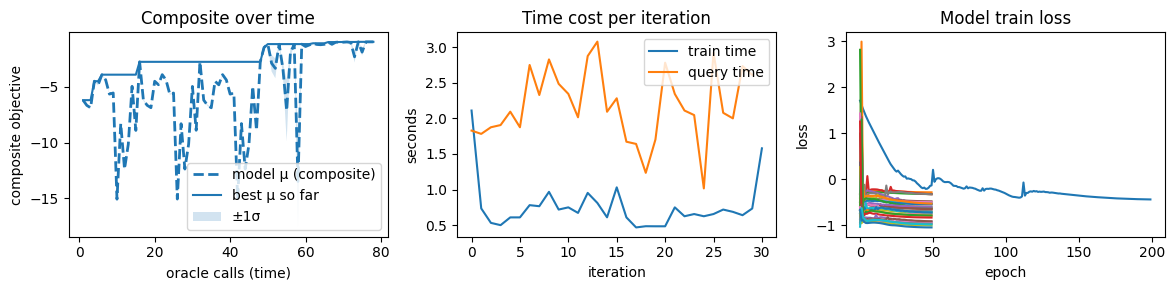

In [13]:
fig,ax, mean = msbo.plot_composite_objective()

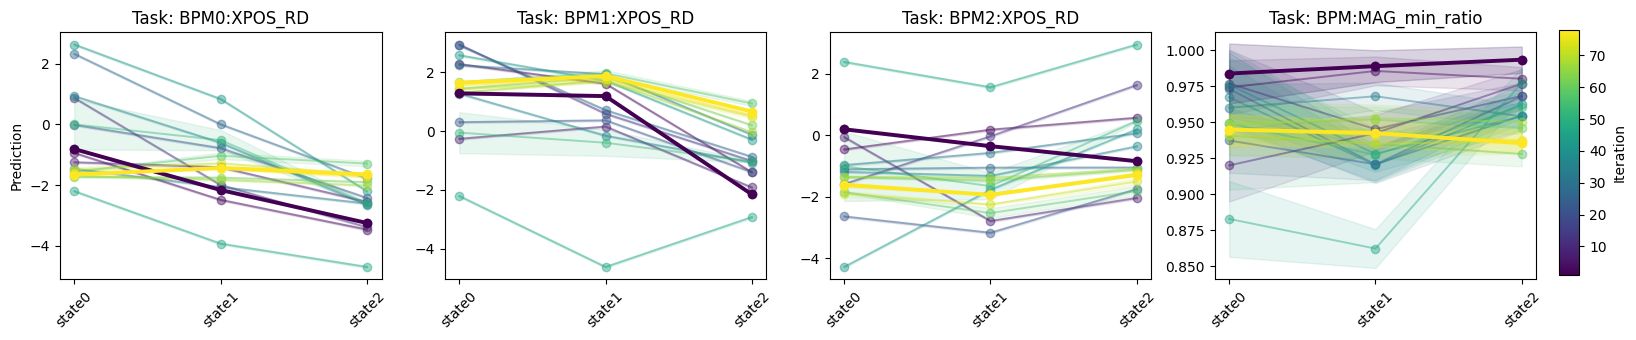

In [14]:
fig, axes = msbo.plot_state_predictions_history()
plt.show()

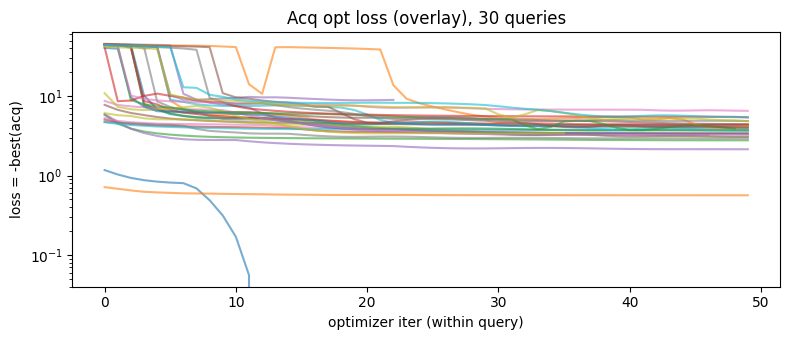

In [15]:
fig,ax = msbo.plot_acq_loss_history()